In [3]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [4]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]

File 0: /Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc
<xarray.Dataset>
Dimensions:            (station: 9, valid_time: 750192)
Coordinates:
  * station            (station) int64 1 2 3 4 5 6 7 8 10
  * valid_time         (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-30T...
    latitude           float64 ...
    longitude          float64 ...
    station_latitude   (station) float64 ...
    station_longitude  (station) float64 ...
Data variables: (12/14)
    u10                (station, valid_time) float32 ...
    v10                (station, valid_time) float32 ...
    d2m                (station, valid_time) float32 ...
    t2m                (station, valid_time) float32 ...
    msl                (station, valid_time) float32 ...
    sst                (station, valid_time) float32 ...
    ...                 ...
    mwd                (station, valid_time) float32 ...
    mwp                (station, valid_time) float32 ...
    swh                (station, valid_

In [5]:
def preprocess(ds):
    return ds.sortby("station") 

datasets = [preprocess(xr.open_dataset(f)) for f in files]
ds = xr.concat(datasets, dim="station")

In [24]:
# Ensure time is sorted (important for derivatives)
ds = ds.sortby("valid_time")

# --- Core helpers (finite differences over hours) ---
def diff_hours(da, hours: int):
    """Finite-difference derivative over 'hours' (value change per hour)."""
    return (da - da.shift(valid_time=hours)) / hours

# --- Wind features ---
u = ds["u10"]
v = ds["v10"]
wind_speed = np.hypot(u, v).rename("wind_speed")

d_wind_1h = diff_hours(wind_speed, 1).rename("d_wind_1h")   # Δwind / 1h
d_wind_6h = diff_hours(wind_speed, 6).rename("d_wind_6h")   # Δwind / 6h

# --- Pressure derivatives (dsp/dt) ---
sp = ds["sp"]
d_sp_1h = diff_hours(sp, 1).rename("d_sp_1h")
d_sp_6h = diff_hours(sp, 6).rename("d_sp_6h")

# --- Tide shifted features ---
tide_lag1h = ds["tide"].shift(valid_time=1).rename("tide_lag1h")
tide_lag6h = ds["tide"].shift(valid_time=6).rename("tide_lag6h")
tide_lag0h = ds["tide"].shift(valid_time=0).rename("tide_lag0h")

# Make sure sorted
ds = ds.sortby("valid_time")

# Pull just tide to a tidy frame
df = ds[["tide"]].to_dataframe().reset_index()
df = df.sort_values(["station", "valid_time"])

# Compute tidal range per station (across all valid_time)
tide_range = (ds["tide"].max(dim="valid_time") - ds["tide"].min(dim="valid_time"))
tide_range = tide_range.rename("tide_range")

# --- Air density (rho_air) ---
# Use sp (Pa) and t2m (K) if available; else fallback to 1.225 kg/m^3
R_d = 287.05  # J kg^-1 K^-1
if "sp" in ds and "t2m" in ds:
    rho_air = (ds["sp"] / (R_d * ds["t2m"])).astype("float32").rename("rho_air")
else:
    rho_air = xr.zeros_like(wind_speed) + 1.225
    rho_air = rho_air.astype("float32").rename("rho_air")

# --- Drag coefficient C_D (Large & Pond style) ---
U = wind_speed
Cd = xr.where(
    U < 11.0,
    1.14e-3,
    xr.where(U <= 25.0, (0.49 + 0.065 * U) * 1e-3, 2.0e-3)
).astype("float32").rename("Cd")

# --- Wind stress components (N/m^2 = Pa) ---
tau_x = (rho_air * Cd * U * u).astype("float32").rename("tau_x")
tau_y = (rho_air * Cd * U * v).astype("float32").rename("tau_y")
tau_mag = (rho_air * Cd * U**2).astype("float32").rename("tau_mag")

# Optional: tendencies (change over 1h/6h), consistent with your diff_hours helper
tau_d1h = diff_hours(tau_mag, 1).astype("float32").rename("d_tau_1h")
tau_d6h = diff_hours(tau_mag, 6).astype("float32").rename("d_tau_6h")

# --- Assemble into one dataset ---
feat_ds = xr.Dataset(
    {
        "wind_speed": wind_speed,
        "d_wind_1h": d_wind_1h,
        "d_wind_6h": d_wind_6h,
        "d_sp_1h": d_sp_1h,
        "d_sp_6h": d_sp_6h,
        "tide_range_12h": tide_range,
        "tide_lag0h": tide_lag0h,
        "tide_lag1h": tide_lag1h,
        "tide_lag6h": tide_lag6h,
        # "d_msl_1h": d_msl_1h,  # uncomment if you computed these
        # "d_msl_6h": d_msl_6h,
        "tau_x": tau_x,
        "tau_y": tau_y,
        "tau_mag": tau_mag,
        "tau_d1h": tau_d1h,
        "tau_d6h": tau_d6h,
    }
)

# Keep original coordinates/attrs
feat_ds = feat_ds.assign_coords(
    station=ds["station"],
    valid_time=ds["valid_time"]
)
for v in feat_ds.data_vars:
    feat_ds[v].attrs.update(ds[v.split("_")[0]].attrs if v.split("_")[0] in ds.data_vars else {})

# Merge features back with original dataset (optional)
ds_engineered = xr.merge([ds, feat_ds])

In [25]:
# exclude target + sea_level + tide from predictors
predictors = [v for v in ds_engineered.data_vars if v not in ["residual", "sea_level", "tide", "longitude", "latitude", "station_longitude", "station_latitude", "station", "valid_time"]]
target = "residual"
df = ds_engineered[predictors + [target]].to_dataframe().reset_index()
df = df.dropna(subset=[target])

# Integrate all factors

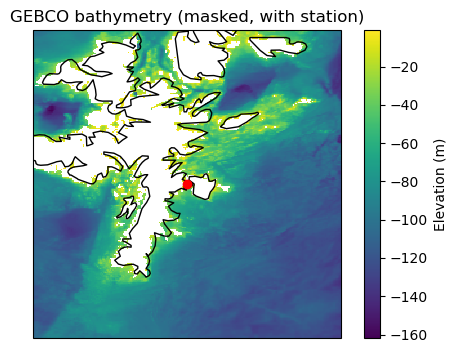

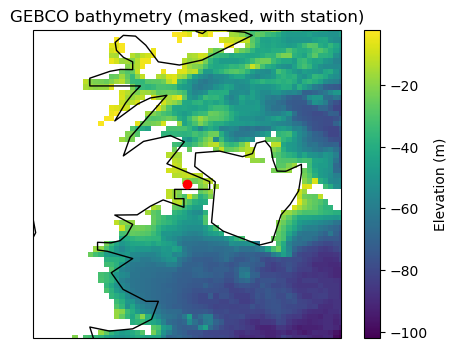

In [ ]:
# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

#ds = xr.open_mfdataset(nc_files, combine='by_coords')  # or combine='nested' with concat_dim='time' if needed
ds_sealevel = xr.open_dataset("/Users/lb962/Documents/GitHub/ESL/data/processed/filtered_GESLA_sea_level.nc")
# extract station ids and their lat/lon
stations = ds_sealevel['station'].values
lats = ds_sealevel['latitude'].values
lons = ds_sealevel['longitude'].values
station = ds_sealevel['station'].values

# build mapping from (lat, lon) to station index
latlon_to_station = {
    (float(lat), float(lon)): int(stn)
    for stn, lat, lon in zip(stations, lats, lons)
}

# if you want unique lat/lon pairs:
unique_latlon = list(latlon_to_station.keys())

# Function to extract square around a lat/lon
def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat + half, lat - half),  # GEBCO lat usually descending
        lon=slice(lon - half, lon + half),
        method="nearest"
    )

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    return ds_tile.assign(elevation=ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5))

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    """Fast spatial slice using coordinate indices."""
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat - half, lat + half),
        lon=slice(lon - half, lon + half)
    )

# --- Prep: ensure coordinates are monotonic so .sel(slice) is efficient ---
GEBCO_ds = GEBCO_ds.sortby(["lat", "lon"])

# Available resolutions (keep all for each point)
resolutions = [0.1, 0.25, 1.0, 3.0, 10.0]

# Initialize results dict
results = {f"{r}x{r}": [] for r in resolutions}
#results = {r: [] for r in resolutions}

# Build tiles for every (lat, lon) at every resolution
for lat, lon in unique_latlon:
    for size in resolutions:
        key = f"{size}x{size}"
        results[key].append(extract_square(GEBCO_ds, lat, lon, size))

# Example usage:
plot_tile(results["1.0x1.0"][0])
plot_tile(results["0.25x0.25"][0])

In [9]:
import numpy as np
import xarray as xr

def to_128x128(ds_tile: xr.Dataset, H: int = 224, W: int = 224) -> xr.Dataset:
    """
    Quick, vectorized resize of a GEBCO tile to (H,W) using xarray's interp.
    Works for all numeric vars defined on (lat, lon). Keeps dask laziness.
    """
    # Build uniform target coords spanning the tile extent (ascending)
    lat0, lat1 = float(ds_tile.lat.min()), float(ds_tile.lat.max())
    lon0, lon1 = float(ds_tile.lon.min()), float(ds_tile.lon.max())
    new_lat = np.linspace(lat0, lat1, H, dtype=np.float32)
    new_lon = np.linspace(lon0, lon1, W, dtype=np.float32)

    # Interpolate all variables defined on (lat, lon)
    return ds_tile.interp(lat=new_lat, lon=new_lon, method="linear")

# --- apply to every tile in your dict ---
results_128 = {k: [to_128x128(ds) for ds in tiles] for k, tiles in results.items()}

# sanity check (first available tile per bucket should be 128x128)
for k, tiles in results_128.items():
    if tiles:
        shp = tiles[0]["elevation"].shape
        assert shp == (224, 224), f"{k} -> {shp}, expected (128, 128)"

del GEBCO_ds

In [10]:
# choose one tile size to start
size_key = "1.0x1.0"  # e.g. "0.25x0.25", "1x1", "3x3", ...

tiles = results_128[size_key]  # list of xarray.Dataset tiles (lat, lon -> elevation)

# station id for each tile (same order you built tiles from unique_latlon)
stations_for_tiles = [latlon_to_station[(float(lat), float(lon))] for (lat, lon) in unique_latlon]

# guard in case of length mismatch
n = min(len(tiles), len(stations_for_tiles))
tiles = tiles[:n]
stations_for_tiles = stations_for_tiles[:n]
print(f"Using {n} tiles from results_128[{size_key!r}]")

Using 182 tiles from results_128['1.0x1.0']


In [13]:
import numpy as np, pandas as pd, torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

torch.manual_seed(0); np.random.seed(0)


In [15]:
time_cols = [c for c in df.columns
             if c not in ['station','residual','time']
             and np.issubdtype(df[c].dtype, np.number)]

In [16]:
class AE(nn.Module):
    def __init__(self, d=16):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1,8,3,2,1), nn.ReLU(),
            nn.Conv2d(8,16,3,2,1), nn.ReLU(),
            nn.Conv2d(16,32,3,2,1), nn.ReLU(),
            nn.Conv2d(32,64,3,2,1), nn.ReLU(),
        )
        self.flat = nn.Flatten()
        self.fc = nn.Linear(64*8*8, d)
        self.fc_dec = nn.Linear(d, 64*8*8)
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(64,32,3,2,1,1), nn.ReLU(),
            nn.ConvTranspose2d(32,16,3,2,1,1), nn.ReLU(),
            nn.ConvTranspose2d(16,8,3,2,1,1), nn.ReLU(),
            nn.ConvTranspose2d(8,1,3,2,1,1), nn.Sigmoid(),
        )
    def embed(self,x): return self.fc(self.flat(self.enc(x)))
    def forward(self,x): 
        z = self.embed(x)
        z = self.fc_dec(z).view(-1,64,8,8)
        return self.dec(z)


In [17]:
class ImgDS(Dataset):
    def __init__(self, sids, res128):
        self.sids = [str(s) for s in sids]
        self.res128 = res128
    def __len__(self): return len(self.sids)
    def __getitem__(self,i):
        sid = self.sids[i]
        img = self.res128[str(sid)]
        if img.ndim==3: img = img[0]
        img = img.astype('float32')
        if img.max() > 1.5: img /= 255.0
        return torch.from_numpy(img[None,...]), sid


In [26]:
df

,station,valid_time,u10,v10,d2m,t2m,msl,sst,sp,tp,...,tau_x,tau_y,tau_mag,tau_d1h,tau_d6h,residual,latitude,longitude,station_latitude,station_longitude
166560,1,1959-01-01 00:00:00,5.209442,-0.476517,273.325043,277.608032,99514.0000,281.192871,99330.000000,0.000000e+00,...,0.038725,-0.003542,0.038886,-0.007193,-0.014753,0.162691,60.155,-1.14,60.155000,-1.140000
166561,1,1959-01-01 01:00:00,4.730118,0.914398,273.219055,277.611084,99477.7500,281.192871,99293.359375,0.000000e+00,...,0.032370,0.006258,0.032969,-0.005917,-0.015379,0.208663,60.155,-1.14,60.155000,-1.140000
166562,1,1959-01-01 02:00:00,3.705322,1.766830,273.066772,277.564209,99463.5625,281.192871,99280.609375,0.000000e+00,...,0.021607,0.010303,0.023937,-0.009032,-0.015179,0.214002,60.155,-1.14,60.155000,-1.140000
166563,1,1959-01-01 03:00:00,2.467941,2.737152,272.980896,277.247223,99364.7500,281.192871,99181.257812,0.000000e+00,...,0.012922,0.014332,0.019297,-0.004640,-0.014020,0.234422,60.155,-1.14,60.155000,-1.140000
166564,1,1959-01-01 04:00:00,0.905975,3.611069,273.116028,277.186737,99262.3125,281.192871,99078.859375,1.382828e-05,...,0.004788,0.019085,0.019676,0.000379,-0.004350,0.217608,60.155,-1.14,60.155000,-1.140000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6711595,10,2020-12-31 19:00:00,-3.155624,0.394073,270.571167,275.282654,100506.3750,281.013184,100452.906250,4.768372e-07,...,-0.014543,0.001816,0.014656,-0.004532,-0.002606,-0.311764,60.155,-1.14,63.425224,9.101504
6711596,10,2020-12-31 20:00:00,-2.683228,0.568283,270.544922,275.246338,100532.9375,281.013184,100479.539062,4.768372e-07,...,-0.010670,0.002260,0.010906,-0.003750,-0.003239,-0.405506,60.155,-1.14,63.425224,9.101504
6711597,10,2020-12-31 21:00:00,-2.282608,0.470184,270.578796,275.213379,100588.1250,281.013184,100533.960938,4.768372e-07,...,-0.007718,0.001590,0.007880,-0.003027,-0.003423,-0.429162,60.155,-1.14,63.425224,9.101504
6711598,10,2020-12-31 22:00:00,-3.612488,0.751968,270.602295,274.944611,100654.9375,281.028076,100601.117188,1.430511e-06,...,-0.019370,0.004032,0.019785,0.011906,-0.001388,-0.435724,60.155,-1.14,63.425224,9.101504


In [34]:
df_imgs

,station,valid_time,u10,v10,d2m,t2m,msl,sst,sp,tp,...,tau_x,tau_y,tau_mag,tau_d1h,tau_d6h,residual,latitude,longitude,station_latitude,station_longitude
166560,1,1959-01-01 00:00:00,5.209442,-0.476517,273.325043,277.608032,99514.0000,281.192871,99330.000000,0.000000e+00,...,0.038725,-0.003542,0.038886,-0.007193,-0.014753,0.162691,60.155,-1.14,60.155000,-1.140000
166561,1,1959-01-01 01:00:00,4.730118,0.914398,273.219055,277.611084,99477.7500,281.192871,99293.359375,0.000000e+00,...,0.032370,0.006258,0.032969,-0.005917,-0.015379,0.208663,60.155,-1.14,60.155000,-1.140000
166562,1,1959-01-01 02:00:00,3.705322,1.766830,273.066772,277.564209,99463.5625,281.192871,99280.609375,0.000000e+00,...,0.021607,0.010303,0.023937,-0.009032,-0.015179,0.214002,60.155,-1.14,60.155000,-1.140000
166563,1,1959-01-01 03:00:00,2.467941,2.737152,272.980896,277.247223,99364.7500,281.192871,99181.257812,0.000000e+00,...,0.012922,0.014332,0.019297,-0.004640,-0.014020,0.234422,60.155,-1.14,60.155000,-1.140000
166564,1,1959-01-01 04:00:00,0.905975,3.611069,273.116028,277.186737,99262.3125,281.192871,99078.859375,1.382828e-05,...,0.004788,0.019085,0.019676,0.000379,-0.004350,0.217608,60.155,-1.14,60.155000,-1.140000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6711595,10,2020-12-31 19:00:00,-3.155624,0.394073,270.571167,275.282654,100506.3750,281.013184,100452.906250,4.768372e-07,...,-0.014543,0.001816,0.014656,-0.004532,-0.002606,-0.311764,60.155,-1.14,63.425224,9.101504
6711596,10,2020-12-31 20:00:00,-2.683228,0.568283,270.544922,275.246338,100532.9375,281.013184,100479.539062,4.768372e-07,...,-0.010670,0.002260,0.010906,-0.003750,-0.003239,-0.405506,60.155,-1.14,63.425224,9.101504
6711597,10,2020-12-31 21:00:00,-2.282608,0.470184,270.578796,275.213379,100588.1250,281.013184,100533.960938,4.768372e-07,...,-0.007718,0.001590,0.007880,-0.003027,-0.003423,-0.429162,60.155,-1.14,63.425224,9.101504
6711598,10,2020-12-31 22:00:00,-3.612488,0.751968,270.602295,274.944611,100654.9375,281.028076,100601.117188,1.430511e-06,...,-0.019370,0.004032,0.019785,0.011906,-0.001388,-0.435724,60.155,-1.14,63.425224,9.101504


In [37]:
import numpy as np, pandas as pd, re
from collections import defaultdict

def to_minus180_180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0

def _label_from_key(k):
    s = str(k)
    m = re.match(r'^\s*([0-9]*\.?[0-9]+)\s*x', s)  # "0.25x0.25" -> 0.25
    if m: return f"{float(m.group(1)):g}"
    try:   return f"{float(s):g}"                  # "0.1" -> "0.1"
    except: return s.strip()

def _img2d(a):
    a = np.asarray(a)
    if a.ndim == 3 and a.shape[0] == 1:  # (1,128,128)
        a = a[0]
    if a.ndim == 3 and a.shape[-1] == 1: # (128,128,1)
        a = a[..., 0]
    return a.astype(np.float32)

def _pick_lat(meta):
    for k in ('station_latitude','latitude','lat','y','Latitude','LAT'):
        if k in meta: return float(meta[k])
    raise KeyError("latitude key not found in meta")

def _pick_lon(meta):
    for k in ('station_longitude','longitude','lon','lng','x','Longitude','LON'):
        if k in meta: return float(meta[k])
    raise KeyError("longitude key not found in meta")
def _as_iter_triplets(val):
    """
    Yield (lat, lon, image_ndarray) from a resolution bucket `val`.
    Supports:
      - dict with arrays: {'images'/'maps', 'lat'/'latitude', 'lon'/'longitude'}
      - list of dicts: each has 'image' and lat/lon fields
      - dict of entries: either value is dict with 'image'+lat/lon, or key is (lat,lon) / 'lat,lon' and value is image
    """
    # Case A: dict with arrays
    if isinstance(val, dict):
        # find image array(s)
        img_key = next((k for k in ('images','image','maps','imgs') if k in val), None)
        lat_key = next((k for k in ('lat','latitude','station_latitude') if k in val), None)
        lon_key = next((k for k in ('lon','lng','longitude','station_longitude') if k in val), None)
        if img_key and lat_key and lon_key:
            imgs = val[img_key]
            lats = val[lat_key]
            lons = val[lon_key]
            for la, lo, im in zip(lats, lons, imgs):
                yield float(la), float(lo), _img2d(im)
            return

    # Case B: list/tuple of dict-like entries
    if isinstance(val, (list, tuple)):
        for item in val:
            if isinstance(item, dict):
                im = item.get('image') or item.get('img') or item.get('map')
                if im is None:
                    continue
                try:
                    la = _pick_lat(item); lo = _pick_lon(item)
                except KeyError:
                    continue
                yield la, lo, _img2d(im)
        return

    # Case C: dict of entries (values dict or image; keys may be coords)
    if isinstance(val, dict):
        for k2, v2 in val.items():
            # value is dict with image + meta
            if isinstance(v2, dict):
                im = v2.get('image') or v2.get('img') or v2.get('map')
                if im is None:
                    continue
                try:
                    la = _pick_lat(v2); lo = _pick_lon(v2)
                except KeyError:
                    continue
                yield la, lo, _img2d(im)
                continue
            # value is image; key encodes coordinates
            if isinstance(v2, np.ndarray):
                # key as tuple/list (lat,lon)
                if isinstance(k2, (tuple, list)) and len(k2) == 2:
                    la, lo = float(k2[0]), float(k2[1])
                    yield la, lo, _img2d(v2)
                    continue
                # key as "lat,lon" string
                if isinstance(k2, str) and ',' in k2:
                    try:
                        la_s, lo_s = k2.split(',', 1)
                        la, lo = float(la_s), float(lo_s)
                        yield la, lo, _img2d(v2)
                        continue
                    except Exception:
                        pass
def merge_df_with_results_by_latlon(df, results_128,
                                    lat_col='station_latitude', lon_col='station_longitude',
                                    prec=6):
    if lat_col not in df.columns or lon_col not in df.columns:
        raise KeyError(f"Expected '{lat_col}' and '{lon_col}' in df")

    out = df.copy()
    out['lat_key'] = out[lat_col].astype(float).round(prec)
    out['lon_key'] = to_minus180_180(out[lon_col].astype(float).values).round(prec)

    created = []
    for res_key, bucket in results_128.items():
        lab = _label_from_key(res_key)
        col = f'img_{lab}'
        # Build a small table (lat_key, lon_key, averaged_image)
        sums, cnts = {}, {}
        n_seen = 0
        for la, lo, im in _as_iter_triplets(bucket):
            n_seen += 1
            la_k = round(float(la), prec)
            lo_k = round(float(to_minus180_180(float(lo))), prec)
            key = (la_k, lo_k)
            if key in sums:
                sums[key] = sums[key] + im
                cnts[key] += 1
            else:
                sums[key] = im.copy()
                cnts[key] = 1
        if not sums:
            print(f"[info] Resolution '{res_key}' -> 0 entries recognised (skipping).")
            continue

        rows = [{'lat_key': k[0], 'lon_key': k[1], col: sums[k] / cnts[k]} for k in sums]
        df_res = pd.DataFrame(rows)

        # left merge
        out = out.merge(df_res, how='left', on=['lat_key','lon_key'])

        # coalesce possible suffixes
        if f"{col}_x" in out and f"{col}_y" in out:
            out[col] = out[f"{col}_y"].combine_first(out[f"{col}_x"])
            out = out.drop(columns=[f"{col}_x", f"{col}_y"])
        elif f"{col}_y" in out:
            out[col] = out[f"{col}_y"]
            out = out.drop(columns=[f"{col}_y"])

        created.append(col)
        matched = out[col].apply(lambda v: isinstance(v, np.ndarray)).sum()
        print(f"[ok] {col}: recognised {n_seen} items; matched {matched}/{len(out)} df rows.")

    # drop helper keys
    out = out.drop(columns=['lat_key','lon_key'])
    if not created:
        print("No image columns were created. Check the layout inside each results_128[resolution].")
    else:
        print("Image columns created:", created)
    return out
df_imgs = merge_df_with_results_by_latlon(
    df,
    results_128,
    lat_col='station_latitude',     # change if your df uses different names
    lon_col='station_longitude',
    prec=6                           # increase to 7–8 for stricter, or 4 for looser
)


[info] Resolution '0.1x0.1' -> 0 entries recognised (skipping).
[info] Resolution '0.25x0.25' -> 0 entries recognised (skipping).
[info] Resolution '1.0x1.0' -> 0 entries recognised (skipping).
[info] Resolution '3.0x3.0' -> 0 entries recognised (skipping).
[info] Resolution '10.0x10.0' -> 0 entries recognised (skipping).
No image columns were created. Check the layout inside each results_128[resolution].


In [40]:
results_128['0.1x0.1'][0]

<xarray.Dataset>
Dimensions:    (lat: 224, lon: 224)
Coordinates:
  * lat        (lat) float32 60.11 60.11 60.11 60.11 ... 60.2 60.2 60.2 60.2
  * lon        (lon) float32 -1.19 -1.189 -1.189 -1.188 ... -1.095 -1.094 -1.094
Data variables:
    elevation  (lat, lon) float64 -46.0 -45.69 -45.38 ... -48.79 -48.9 -49.0
Attributes: (12/36)
    title:                           The GEBCO_2024 Grid - a continuous terra...
    summary:                         The GEBCO_2024 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_vertical_units:       meters
    geospatial_vertical_resolution:  1.0
    geospatial_vertical_positive:    up
    identifier_product_doi:          DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    references:                      DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    node_offset:                     1.0

In [11]:
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F, re
from torch.utils.data import Dataset, DataLoader

# ---------------- helpers ----------------
def to_minus180_180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0

def embed_col_name(key):
    """Map resolution key to a nice column name like 'embedding_01', 'embedding_025', 'embedding_1'."""
    s = str(key)
    m = re.match(r'^\s*([0-9]*\.?[0-9]+)\s*x', s)
    try:
        val = float(m.group(1)) if m else float(s)
    except Exception:
        return f"embedding_{s.replace('.', '_')}"
    mapping = {0.1: "01", 0.25: "025", 1.0: "1", 3.0: "3", 10.0: "10"}
    suf = mapping.get(val, f"{val:g}".replace('.', '_'))
    return f"embedding_{suf}"

def tile_to_tensor128(ds_tile, keep_ocean_only=True):
    da = ds_tile["elevation"].astype("float32").sortby(["lat","lon"])
    if keep_ocean_only:
        da = da.where(da <= -0.5)
    lat_new = np.linspace(float(da.lat.min()), float(da.lat.max()), 128)
    lon_new = np.linspace(float(da.lon.min()), float(da.lon.max()), 128)
    da = da.interp(lat=lat_new, lon=lon_new)

    arr = np.nan_to_num(da.values, nan=0.0).astype("float32")
    lo, hi = np.percentile(arr, [1,99])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = arr.min(), arr.max()
    arr  = np.clip(arr, lo, hi)
    elev = 2*(arr - lo) / max(hi - lo, 1e-6) - 1.0

    x = torch.from_numpy(elev).unsqueeze(0)  # (1,128,128)
    x4 = x.unsqueeze(0)
    kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32).view(1,1,3,3)
    ky = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32).view(1,1,3,3)
    sx = F.conv2d(x4, kx, padding=1); sy = F.conv2d(x4, ky, padding=1)
    s_scale = torch.quantile(torch.abs(torch.cat([sx.flatten(), sy.flatten()])), 0.99).clamp_min(1e-6)
    sx = (sx / s_scale).clamp(-1,1); sy = (sy / s_scale).clamp(-1,1)
    return torch.cat([x, sx.squeeze(0), sy.squeeze(0)], dim=0)  # (3,128,128)

class TilesDS(Dataset):
    def __init__(self, tiles): self.tiles = tiles
    def __len__(self): return len(self.tiles)
    def __getitem__(self, i): return tile_to_tensor128(self.tiles[i])

class TinyCNNEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.Linear(256, out_dim)
        )
    def forward(self, x): return self.net(x)

# ------------- 1) encode all resolutions into features/meta -------------
device = torch.device("cpu")
encoder = TinyCNNEncoder(128).eval().to(device)

features_by_location = {}   # {res_key: [np.array(128), ...]}
meta_by_location     = {}   # {res_key: [{"station_latitude":..,"station_longitude":..}, ...]}

# coords built from unique_latlon, assume same order used to create each results_128[key]
base_coords = [(float(lat), float(lon)) for (lat, lon) in unique_latlon]

for res_key, tiles in results_128.items():
    # align coords length to tiles length
    n = min(len(tiles), len(base_coords))
    if n == 0:
        continue
    coords = base_coords[:n]
    loader = DataLoader(TilesDS(tiles[:n]), batch_size=32, shuffle=False, num_workers=0)

    embs = []
    with torch.no_grad():
        for X in loader:
            Z = encoder(X.to(device)).cpu().numpy()  # (B,128)
            embs.append(Z)
    feats = np.vstack(embs)  # (n,128)

    metas = [{"station_latitude": lt, "station_longitude": to_minus180_180(ln)} for (lt, ln) in coords]

    features_by_location[res_key] = [feats[i] for i in range(n)]
    meta_by_location[res_key]     = metas

print("Encoded resolutions:", list(features_by_location.keys()))

# ------------- 2) merge into df as columns embedding_* -------------
PREC = 6
lat_col = "station_latitude"  if "station_latitude"  in df.columns else "latitude"
lon_col = "station_longitude" if "station_longitude" in df.columns else "longitude"

df_out = df.copy()
df_out["lat_key"] = df_out[lat_col].astype(float).round(PREC)
df_out["lon_key"] = to_minus180_180(df_out[lon_col].astype(float).values).round(PREC)

for res_key, feats in features_by_location.items():
    metas = meta_by_location[res_key]
    col   = embed_col_name(res_key)

    # average duplicates per (lat,lon) if any
    sums, cnts = {}, {}
    for i, meta in enumerate(metas):
        la_k = round(float(meta["station_latitude"]), PREC)
        lo_k = round(float(meta["station_longitude"]), PREC)
        key = (la_k, lo_k)
        vec = np.asarray(feats[i], dtype=np.float32)
        if key in sums:
            sums[key] += vec; cnts[key] += 1
        else:
            sums[key] = vec.copy(); cnts[key] = 1
    rows = [{"lat_key": k[0], "lon_key": k[1], col: sums[k] / cnts[k]} for k in sums]
    df_res = pd.DataFrame(rows)

    # left-merge (keep all df rows)
    df_out = df_out.merge(df_res, how="left", on=["lat_key","lon_key"])

# cleanup helper keys
df_out = df_out.drop(columns=["lat_key","lon_key"])

print("New embedding columns:", [c for c in df_out.columns if c.startswith("embedding_")])
print(df_out.head(3))


: 

In [9]:
# --- pick size & line up coords with tiles ---
size_key = "1.0x1.0"  # or "0.25x0.25", "3x3", ...
tiles = results_128[size_key]
coords = [(float(lat), float(lon)) for (lat, lon) in unique_latlon][:len(tiles)]
tiles = tiles[:len(coords)]

import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# --- tile -> (3,128,128) ---
def tile_to_tensor128(ds_tile, keep_ocean_only=True):
    da = ds_tile["elevation"].astype("float32").sortby(["lat","lon"])
    if keep_ocean_only:
        da = da.where(da <= -0.5)
    lat_new = np.linspace(float(da.lat.min()), float(da.lat.max()), 128)
    lon_new = np.linspace(float(da.lon.min()), float(da.lon.max()), 128)
    da = da.interp(lat=lat_new, lon=lon_new)

    arr = np.nan_to_num(da.values, nan=0.0).astype("float32")
    lo, hi = np.percentile(arr, [1,99])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = arr.min(), arr.max()
    arr  = np.clip(arr, lo, hi)
    elev = 2*(arr - lo) / max(hi - lo, 1e-6) - 1.0

    x = torch.from_numpy(elev).unsqueeze(0)  # (1,128,128)
    x4 = x.unsqueeze(0)
    kx = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=torch.float32).view(1,1,3,3)
    ky = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=torch.float32).view(1,1,3,3)
    sx = F.conv2d(x4, kx, padding=1); sy = F.conv2d(x4, ky, padding=1)
    s_scale = torch.quantile(torch.abs(torch.cat([sx.flatten(), sy.flatten()])), 0.99).clamp_min(1e-6)
    sx = (sx / s_scale).clamp(-1,1); sy = (sy / s_scale).clamp(-1,1)
    return torch.cat([x, sx.squeeze(0), sy.squeeze(0)], dim=0)  # (3,128,128)

class TilesDS(Dataset):
    def __init__(self, tiles): self.tiles = tiles
    def __len__(self): return len(self.tiles)
    def __getitem__(self, i): return tile_to_tensor128(self.tiles[i])

# --- tiny encoder to get embeddings ---
class TinyCNNEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32,64,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128,3,padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3,padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)), nn.Flatten(),
            nn.Linear(256, out_dim)
        )
    def forward(self, x): return self.net(x)

encoder = TinyCNNEncoder(128).eval().to("cpu")
loader  = DataLoader(TilesDS(tiles), batch_size=32, shuffle=False, num_workers=0)

# --- encode all tiles ---
emb_list = []
with torch.no_grad():
    for X in loader:
        Z = encoder(X).cpu().numpy()  # (B,128)
        emb_list.append(Z)
emb_arr = np.vstack(emb_list)  # (N,128)

# --- build embedding table keyed by (lat,lon) ---
emb_cols = [f"emb_{i}" for i in range(emb_arr.shape[1])]
emb_df = pd.DataFrame(emb_arr, columns=emb_cols)
emb_df["latitude"]  = [lt for (lt, _) in coords]
emb_df["longitude"] = [ln for (_, ln) in coords]
# in case of duplicate coords (rare), average
emb_df = emb_df.groupby(["latitude","longitude"], as_index=False).mean()

# --- merge into df by lat/lon (rounded keys for safety) ---
df["valid_time"] = pd.to_datetime(df["valid_time"], errors="coerce")
lat_col = "station_latitude"  if "station_latitude"  in df.columns else "latitude"
lon_col = "station_longitude" if "station_longitude" in df.columns else "longitude"

dec = 4
emb_df["lat_key"] = emb_df["latitude"].round(dec)
emb_df["lon_key"] = emb_df["longitude"].round(dec)
df["_lat_key"]    = df[lat_col].round(dec)
df["_lon_key"]    = df[lon_col].round(dec)

df_merged = df.merge(
    emb_df.drop(columns=["latitude","longitude"]),
    left_on=["_lat_key","_lon_key"],
    right_on=["lat_key","lon_key"],
    how="inner"
).drop(columns=["_lat_key","_lon_key","lat_key","lon_key"])

print("Merged shape:", df_merged.shape)
print(df_merged.head(3))


: 